In [3]:
!pip install nvcc4jupyter
%load_ext nvcc4jupyter

Detected platform "Colab". Running its setup...
Source files will be saved in "/tmp/tmphvxumxvo".


In [7]:
%%cuda
#include <stdio.h>
#include <stdlib.h>
#include <omp.h>

#define WIDTH 512
#define HEIGHT 512
#define FILTER_SIZE 3

// Choose filter: 0 = Gaussian, 1 = Sobel
#define FILTER_TYPE 1

__constant__ float d_filter[FILTER_SIZE * FILTER_SIZE];

// CUDA kernel
__global__ void convolution(unsigned char *input, unsigned char *output) {
    int x = blockIdx.x * blockDim.x + threadIdx.x;
    int y = blockIdx.y * blockDim.y + threadIdx.y;

    int half = FILTER_SIZE / 2;

    if (x >= WIDTH || y >= HEIGHT) return;

    float sum = 0.0;

    for (int fy = -half; fy <= half; fy++) {
        for (int fx = -half; fx <= half; fx++) {

            int ix = min(max(x + fx, 0), WIDTH - 1);
            int iy = min(max(y + fy, 0), HEIGHT - 1);

            float pixel = input[iy * WIDTH + ix];
            float coeff = d_filter[(fy + half) * FILTER_SIZE + (fx + half)];

            sum += pixel * coeff;
        }
    }

    // Clamp result
    if (sum < 0) sum = 0;
    if (sum > 255) sum = 255;

    output[y * WIDTH + x] = (unsigned char)sum;
}

// Save PGM image
void savePGM(const char *filename, unsigned char *data) {
    FILE *f = fopen(filename, "wb");
    fprintf(f, "P5\n%d %d\n255\n", WIDTH, HEIGHT);
    fwrite(data, sizeof(unsigned char), WIDTH * HEIGHT, f);
    fclose(f);
}

int main() {

    int size = WIDTH * HEIGHT;

    unsigned char *input = (unsigned char*)malloc(size);
    unsigned char *output = (unsigned char*)malloc(size);

    // OpenMP parallel image generation
    #pragma omp parallel for
    for (int i = 0; i < size; i++) {
        input[i] = rand() % 256;
    }

    float h_filter[FILTER_SIZE * FILTER_SIZE];

    // Select filter
    if (FILTER_TYPE == 0) {
        // Gaussian Blur
        float temp[9] = {
            1/16.0, 2/16.0, 1/16.0,
            2/16.0, 4/16.0, 2/16.0,
            1/16.0, 2/16.0, 1/16.0
        };
        for (int i = 0; i < 9; i++) h_filter[i] = temp[i];
        printf("Using Gaussian Blur\n");
    } else {
        // Sobel Edge Detection (X direction)
        float temp[9] = {
            -1, 0, 1,
            -2, 0, 2,
            -1, 0, 1
        };
        for (int i = 0; i < 9; i++) h_filter[i] = temp[i];
        printf("Using Sobel Edge Detection\n");
    }

    // Copy filter to GPU
    cudaMemcpyToSymbol(d_filter, h_filter, sizeof(float) * 9);

    unsigned char *d_input, *d_output;
    cudaMalloc(&d_input, size);
    cudaMalloc(&d_output, size);

    cudaMemcpy(d_input, input, size, cudaMemcpyHostToDevice);

    dim3 block(16,16);
    dim3 grid((WIDTH+15)/16, (HEIGHT+15)/16);

    convolution<<<grid, block>>>(d_input, d_output);

    cudaMemcpy(output, d_output, size, cudaMemcpyDeviceToHost);

    // Save images
    savePGM("input.pgm", input);
    savePGM("output.pgm", output);

    printf("Saved input.pgm and output.pgm\n");

    cudaFree(d_input);
    cudaFree(d_output);
    free(input);
    free(output);

    return 0;
}

Using Sobel Edge Detection
Saved input.pgm and output.pgm



(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

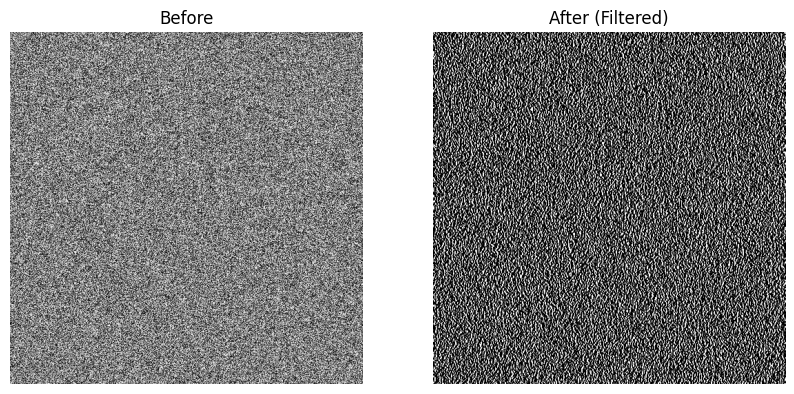

In [8]:
from PIL import Image
import matplotlib.pyplot as plt

img1 = Image.open("input.pgm")
img2 = Image.open("output.pgm")

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Before")
plt.imshow(img1, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("After (Filtered)")
plt.imshow(img2, cmap='gray')
plt.axis('off')

In [9]:
from google.colab import files
files.download("input.pgm")
files.download("output.pgm")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>